<a href="https://colab.research.google.com/github/aaronseymour7/MLQ/blob/main/May4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "jax[cuda12_pip]" \
            pennylane \
            optax \
            flax \
            netket
!pip install pennylane-lightning[tensor]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.5/833.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.6/460

In [ ]:
"""
vqe_pennylane.py — PennyLane uCJ-VQE for the Heisenberg chain.

Pipeline
--------
  LAYER 1  Exact diagonalisation     (SciPy sparse, CPU)
  LAYER 2  NetKet RBM warm-start     (CPU)
  LAYER 3  JAX wavefunction + L-BFGS (GPU via _to_device)
  LAYER 4  PennyLane energy / fidelity evaluation
             device preference: lightning.tensor → default.qubit
"""

from __future__ import annotations

import os
import time as _time

import numpy as np
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize as scipy_minimize

import jax
import jax.numpy as jnp
import optax
import netket as nk
import netket.nn as nknn
import flax.linen as nn

try:
    import pennylane as qml
    print(f"[PennyLane]  version {qml.version()}")
except ImportError:
    raise ImportError("pip install pennylane pennylane-lightning[gpu]")

# ---------------------------------------------------------------------------
# JAX setup
# ---------------------------------------------------------------------------
jax.config.update("jax_enable_x64", True)
_GPU_DEVICES = jax.devices("cpu")
_CPU_DEVICE  = jax.devices("cpu")[0]
_JAX_DEVICE  = _GPU_DEVICES[0] if _GPU_DEVICES else _CPU_DEVICE
print(f"[JAX]  using device: {_JAX_DEVICE}")

def _to_device(x):
    return jax.device_put(x, _JAX_DEVICE)

# ---------------------------------------------------------------------------
# PennyLane device
# ---------------------------------------------------------------------------
_BACKEND_PREF = os.environ.get("PENNYLANE_BACKEND", "lightning.qubit")

def _make_device(n_wires: int):
    bond_dim = int(os.environ.get("MPS_BOND_DIM", "64"))
    for backend in [_BACKEND_PREF, "lightning.qubit", "default.qubit"]:
        try:
            if backend == "lightning.tensor":
                dev = qml.device(backend, wires=n_wires,
                                 method="mps", max_bond_dim=bond_dim)
            else:
                dev = qml.device(backend, wires=n_wires)
            print(f"[PennyLane device]  N={n_wires}  backend={backend}")
            return dev, backend
        except Exception as exc:
            print(f"[PennyLane]  {backend} unavailable ({exc}), trying next…")
    raise RuntimeError("No PennyLane backend could be initialised.")


# =============================================================================
# CONFIG
# =============================================================================
J_COUPLING  = 1.0
PBC         = True
ALPHA       = 3
VMC_SAMPLES = 1024
VMC_STEPS   = 600
K_MAX       = 1
E_TOL       = 5e-3
SEED        = 23
N_RESTARTS  = 3

LBFGS_MAXITER = 300
LBFGS_MAXFUN  = 50_000

VARIANTS = ['re', 'im', 'g']

# Jastrow GPU chunking
JASTROW_CHUNKED = False
JASTROW_CHUNK   = 32


# =============================================================================
# TIMER
# =============================================================================
class Timer:
    def __init__(self):
        self._laps   = {}
        self._starts = {}

    def start(self, name):
        self._starts[name] = _time.perf_counter()

    def stop(self, name):
        if name not in self._starts:
            raise KeyError(f"Timer '{name}' was never started.")
        self._laps[name] = _time.perf_counter() - self._starts.pop(name)
        return self._laps[name]

    def summary(self, title="Runtime summary"):
        W = 54
        print(f"\n{'='*W}\n  {title}\n{'='*W}")
        total = 0.0
        for name, t in self._laps.items():
            total += t
            m, s = divmod(t, 60)
            print(f"  {name:<36}  {int(m):2d}m {s:05.2f}s")
        m, s = divmod(total, 60)
        print(f"  {'─'*48}")
        print(f"  {'TOTAL':<36}  {int(m):2d}m {s:05.2f}s")
        print(f"{'='*W}\n")
        return self._laps.copy()


# =============================================================================
# EXACT DIAGONALISATION  (CPU)
# =============================================================================
def build_basis(n, n_up):
    return np.array([b for b in range(1 << n) if bin(b).count('1') == n_up],
                    dtype=np.int64)


def build_hamiltonian(n, n_up, j=J_COUPLING, pbc=PBC):
    basis   = build_basis(n, n_up)
    idx_map = {int(b): i for i, b in enumerate(basis)}
    H       = lil_matrix((len(basis), len(basis)), dtype=np.float64)
    edges   = ([(i, (i+1) % n) for i in range(n)] if pbc
               else [(i, i+1) for i in range(n-1)])
    for si, sj in edges:
        for row, bits in enumerate(basis):
            zi = 0.5 if (bits >> si) & 1 else -0.5
            zj = 0.5 if (bits >> sj) & 1 else -0.5
            H[row, row] += j * zi * zj
            if ((bits >> si) & 1) != ((bits >> sj) & 1):
                fl  = bits ^ (1 << si) ^ (1 << sj)
                col = idx_map.get(int(fl), -1)
                if col >= 0:
                    H[row, col] += 0.5 * j
    return csr_matrix(H), basis, idx_map


def get_n_up(n):
    return (n + 1) // 2 if n % 2 == 1 else n // 2


# =============================================================================
# JAX HAMILTONIAN  (GPU)
# =============================================================================
def build_jax_hamiltonian(n, n_up, j=J_COUPLING, pbc=PBC):
    basis_list = [b for b in range(1 << n) if bin(b).count('1') == n_up]
    idx_map    = {b: i for i, b in enumerate(basis_list)}
    rows, cols, vals = [], [], []
    edges = ([(i, (i+1) % n) for i in range(n)] if pbc
             else [(i, i+1) for i in range(n-1)])
    for i, js in edges:
        for row, bits in enumerate(basis_list):
            zi = 0.5 if (bits >> i) & 1 else -0.5
            zj = 0.5 if (bits >> js) & 1 else -0.5
            rows.append(row); cols.append(row); vals.append(j * zi * zj)
            if ((bits >> i) & 1) != ((bits >> js) & 1):
                fl = bits ^ (1 << i) ^ (1 << js)
                if fl in idx_map:
                    rows.append(row)
                    cols.append(idx_map[fl])
                    vals.append(0.5 * j)
    h_rows = _to_device(jnp.array(rows, dtype=jnp.int32))
    h_cols = _to_device(jnp.array(cols, dtype=jnp.int32))
    h_vals = _to_device(jnp.array(vals, dtype=jnp.float64))
    return h_rows, h_cols, h_vals


def make_apply_H(h_rows, h_cols, h_vals, dim):
    @jax.jit
    def apply_H(psi):
        return (jnp.zeros(dim, dtype=psi.dtype)
                .at[h_rows].add(h_vals * psi[h_cols]))
    return apply_H


def neel_state(n, n_up, basis, idx_map):
    neel_bits = sum(1 << i for i in range(n) if i % 2 == 0)
    psi = jnp.zeros(len(basis), dtype=jnp.complex128)
    psi = psi.at[idx_map[neel_bits]].set(1.0)
    return _to_device(psi)


# =============================================================================
# JASTROW
# =============================================================================
def build_jastrow_indices(n, basis):
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    pair_i_np = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j_np = np.array([p[1] for p in pairs], dtype=np.int32)
    basis_bits_gpu = _to_device(jnp.array(basis, dtype=jnp.int32))
    return pair_i_np, pair_j_np, basis_bits_gpu


def _make_jastrow_phase_fn(pair_i_np, pair_j_np, basis_bits_gpu):
    pi_gpu = _to_device(jnp.array(pair_i_np, dtype=jnp.int32))
    pj_gpu = _to_device(jnp.array(pair_j_np, dtype=jnp.int32))

    if not JASTROW_CHUNKED:
        def _occ_product(i, j):
            bi = (basis_bits_gpu >> i.astype(jnp.int32)) & 1
            bj = (basis_bits_gpu >> j.astype(jnp.int32)) & 1
            return (bi * bj).astype(jnp.float64)

        _occ_mat_fn = jax.vmap(_occ_product)

        @jax.jit
        def jastrow_phase(theta_J):
            return jnp.dot(theta_J, _occ_mat_fn(pi_gpu, pj_gpu))
    else:
        n_pair = pair_i_np.shape[0]
        chunk  = JASTROW_CHUNK

        @jax.jit
        def jastrow_phase(theta_J):
            phase = jnp.zeros(basis_bits_gpu.shape[0], dtype=jnp.float64)
            for start in range(0, n_pair, chunk):
                end  = min(start + chunk, n_pair)
                pi_c = pi_gpu[start:end]
                pj_c = pj_gpu[start:end]
                th_c = theta_J[start:end]
                def _occ_c(i, j):
                    bi = (basis_bits_gpu >> i.astype(jnp.int32)) & 1
                    bj = (basis_bits_gpu >> j.astype(jnp.int32)) & 1
                    return (bi * bj).astype(jnp.float64)
                phase = phase + jnp.dot(th_c, jax.vmap(_occ_c)(pi_c, pj_c))
            return phase

    return jastrow_phase


def apply_jastrow(psi, theta_J, jastrow_phase_fn):
    return psi * jnp.exp(1j * jastrow_phase_fn(theta_J))


# =============================================================================
# GIVENS PAIRS
# =============================================================================
def build_givens_pairs(n, basis, idx_map):
    srcs_ragged, dsts_ragged = [], []
    for i in range(n):
        for j in range(i + 1, n):
            srcs, dsts = [], []
            for row, bits in enumerate(basis):
                if ((bits >> i) & 1) and not ((bits >> j) & 1):
                    flipped = bits ^ (1 << i) ^ (1 << j)
                    if flipped in idx_map:
                        srcs.append(row)
                        dsts.append(idx_map[flipped])
            srcs_ragged.append(np.array(srcs, dtype=np.int32))
            dsts_ragged.append(np.array(dsts, dtype=np.int32))

    counts  = np.array([len(s) for s in srcs_ragged], dtype=np.int32)
    row_ptr = np.zeros(len(counts) + 1, dtype=np.int32)
    row_ptr[1:] = np.cumsum(counts)

    srcs_cat = (np.concatenate(srcs_ragged) if srcs_ragged
                else np.array([], dtype=np.int32))
    dsts_cat = (np.concatenate(dsts_ragged) if dsts_ragged
                else np.array([], dtype=np.int32))

    srcs_flat_gpu = _to_device(jnp.array(srcs_cat, dtype=jnp.int32))
    dsts_flat_gpu = _to_device(jnp.array(dsts_cat, dtype=jnp.int32))

    nnz = len(srcs_cat)
    n_pair = n * (n - 1) // 2
    print(f"[GivensPairs N={n}]  n_pair={n_pair}  total_nnz={nnz}  "
          f"GPU mem≈{nnz*2*4/1e6:.1f} MB  device={_JAX_DEVICE}")
    return srcs_flat_gpu, dsts_flat_gpu, row_ptr


# =============================================================================
# GIVENS SCAN
# =============================================================================
def _givens_scan_csr(psi, thetas, srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                     imag=False):
    n_pair = row_ptr_np.shape[0] - 1
    for k in range(n_pair):
        start = int(row_ptr_np[k])
        end   = int(row_ptr_np[k + 1])
        if start == end:
            continue
        srcs_k  = srcs_flat_gpu[start:end]
        dsts_k  = dsts_flat_gpu[start:end]
        c = jnp.cos(thetas[k])
        s = jnp.sin(thetas[k])
        p_s, p_d = psi[srcs_k], psi[dsts_k]
        if imag:
            new_s =  c * p_s - 1j * s * p_d
            new_d = -1j * s * p_s + c * p_d
        else:
            new_s = c * p_s - s * p_d
            new_d = s * p_s + c * p_d
        psi = psi.at[srcs_k].set(new_s).at[dsts_k].set(new_d)
    return psi


# =============================================================================
# RBM  (NetKet)
# =============================================================================
class RBMModel(nn.Module):
    alpha: int = 1

    @nn.compact
    def __call__(self, x):
        x = x.astype(jnp.complex128)
        a = self.param('visible_bias', nn.initializers.normal(0.05),
                       (x.shape[-1],), jnp.complex128)
        W = nn.Dense(self.alpha * x.shape[-1], use_bias=True,
                     dtype=jnp.complex128, param_dtype=jnp.complex128,
                     kernel_init=nn.initializers.normal(0.05),
                     bias_init=nn.initializers.normal(0.05))
        return jnp.dot(x, a) + jnp.sum(nknn.activation.log_cosh(W(x)), axis=-1)


def run_netket_vmc(n, e_exact, total_sz=None):
    def stop_at_threshold(step, log_data, driver):
        diff = abs(driver.energy.mean.real - e_exact)
        if diff < 1e-6:
            print(f"\n[VMC early stop] step={step}  |ΔE|={diff:.2e}")
            return False
        return True

    n_up = get_n_up(n)
    if total_sz is None:
        total_sz = (n_up - (n - n_up)) / 2.0
    hi  = nk.hilbert.Spin(s=0.5, N=n, total_sz=total_sz)
    ha  = nk.operator.Heisenberg(hilbert=hi,
                                  graph=nk.graph.Chain(n, pbc=PBC),
                                  J=J_COUPLING / 4.0)
    sa  = nk.sampler.MetropolisExchange(hi, n_chains=16,
                                        graph=nk.graph.Chain(n))
    vs  = nk.vqs.MCState(sa, RBMModel(alpha=ALPHA),
                          n_samples=VMC_SAMPLES, seed=SEED)
    opt = optax.sgd(learning_rate=0.05)
    gs  = nk.driver.VMC(hamiltonian=ha, optimizer=opt, variational_state=vs,
                         preconditioner=nk.optimizer.SR(diag_shift=0.01))
    gs.run(n_iter=VMC_STEPS, out=nk.logging.RuntimeLog(),
           callback=stop_at_threshold)
    E_rbm = float(np.real(vs.expect(ha).mean))
    print(f"[VMC]  E_rbm={E_rbm:.6f}  E_exact={e_exact:.6f}")
    return vs, ha


def extract_ucj_correlators(vs, n, basis, idx_map):
    def log_psi(sigma_batch):
        raw = vs.log_value(jnp.array(sigma_batch, dtype=jnp.float32))
        return np.array(raw, dtype=np.complex128)

    basis_arr = np.array(
        [[(1 if (b >> s) & 1 else -1) for s in range(n)] for b in basis],
        dtype=np.float32)

    log_vals = log_psi(basis_arr)
    log_amps = log_vals - np.max(np.real(log_vals))
    psi      = np.exp(log_amps)
    probs    = np.abs(psi) ** 2
    probs   /= probs.sum()

    occ    = (basis_arr + 1) / 2
    n_mean = (probs[:, None] * occ).sum(0)

    nn_mean   = np.einsum('d,di,dj->ij', probs, occ, occ)
    C_jastrow = nn_mean - np.outer(n_mean, n_mean)

    rho = np.diag(n_mean.astype(complex))
    for i in range(n):
        for j in range(i + 1, n):
            mask = (basis_arr[:, i] == 1) & (basis_arr[:, j] == -1)
            if not mask.any():
                continue
            sigma_v       = basis_arr[mask]
            sigma_f       = sigma_v.copy()
            sigma_f[:, i] = -1
            sigma_f[:, j] =  1
            ratio    = np.exp(log_psi(sigma_f) - log_psi(sigma_v))
            jw_signs = np.array([
                (-1) ** int(((sigma_v[k, i+1:j] + 1) / 2).sum())
                for k in range(sigma_v.shape[0])])
            rho_ij    = (probs[mask] * jw_signs * ratio).sum()
            rho[i, j] = rho_ij
            rho[j, i] = np.conj(rho_ij)

    rho_real = np.zeros((n, n), dtype=np.float64)
    rho_imag = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(i + 1, n):
            rho_real[i, j] =  np.real(rho[i, j])
            rho_real[j, i] =  np.real(rho[i, j])
            rho_imag[i, j] =  np.imag(rho[i, j])
            rho_imag[j, i] = -np.imag(rho[i, j])

    print(f"\n[RDM analysis]  N={n}")
    print(f"  max |Im(rho_ij)| = {np.max(np.abs(rho_imag)):.6f}")
    print(f"  max |Re(rho_ij)| = {np.max(np.abs(rho_real)):.6f}")
    return C_jastrow, rho_real, rho_imag


# =============================================================================
# ANSATZ STATE BUILDERS
# =============================================================================
def ucj_state_re(theta, k_layers, psi0, n_pair,
                 srcs_flat_gpu, dsts_flat_gpu, row_ptr_np, jastrow_phase_fn):
    psi = psi0
    for layer in range(k_layers):
        off = layer * 2 * n_pair
        psi = apply_jastrow(psi, theta[off:off+n_pair], jastrow_phase_fn)
        psi = _givens_scan_csr(psi, theta[off+n_pair:off+2*n_pair],
                               srcs_flat_gpu, dsts_flat_gpu, row_ptr_np)
    return psi


def ucj_state_im(theta, k_layers, psi0, n_pair,
                 srcs_flat_gpu, dsts_flat_gpu, row_ptr_np, jastrow_phase_fn):
    psi = psi0
    for layer in range(k_layers):
        off = layer * 2 * n_pair
        psi = apply_jastrow(psi, theta[off:off+n_pair], jastrow_phase_fn)
        psi = _givens_scan_csr(psi, theta[off+n_pair:off+2*n_pair],
                               srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                               imag=True)
    return psi


def ucj_state_g(theta, k_layers, psi0, n_pair,
                srcs_flat_gpu, dsts_flat_gpu, row_ptr_np, jastrow_phase_fn):
    psi = psi0
    for layer in range(k_layers):
        off = layer * 3 * n_pair
        psi = apply_jastrow(psi, theta[off:off+n_pair], jastrow_phase_fn)
        psi = _givens_scan_csr(psi, theta[off+n_pair:off+2*n_pair],
                               srcs_flat_gpu, dsts_flat_gpu, row_ptr_np)
        psi = _givens_scan_csr(psi, theta[off+2*n_pair:off+3*n_pair],
                               srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                               imag=True)
    return psi


def _energy(psi, apply_H):
    norm = jnp.dot(jnp.conj(psi), psi)
    return jnp.real(jnp.dot(jnp.conj(psi), apply_H(psi)) / norm)


def make_energy_grad(variant, n, k_layers, psi0,
                     srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                     jastrow_phase_fn, apply_H):
    n_pair = n * (n - 1) // 2
    _state_fns = {
        're': lambda th: ucj_state_re(th, k_layers, psi0, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'im': lambda th: ucj_state_im(th, k_layers, psi0, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'g':  lambda th: ucj_state_g(th, k_layers, psi0, n_pair,
                                      srcs_flat_gpu, dsts_flat_gpu,
                                      row_ptr_np, jastrow_phase_fn),
    }
    state_fn = _state_fns[variant]

    def efn(theta_gpu):
        return _energy(state_fn(theta_gpu), apply_H)

    jit_val_grad = jax.jit(jax.value_and_grad(efn,holomorphic=False))
    jit_efn      = jax.jit(efn)
    return jit_val_grad, jit_efn


def fidelity(theta, variant, k_layers, psi0, psi_exact_gpu,
             srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
             jastrow_phase_fn, n):
    n_pair    = n * (n - 1) // 2
    theta_gpu = _to_device(jnp.array(theta, dtype=jnp.float64))
    _state_fns = {
        're': lambda th: ucj_state_re(th, k_layers, psi0, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'im': lambda th: ucj_state_im(th, k_layers, psi0, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'g':  lambda th: ucj_state_g(th, k_layers, psi0, n_pair,
                                      srcs_flat_gpu, dsts_flat_gpu,
                                      row_ptr_np, jastrow_phase_fn),
    }
    psi = _state_fns[variant](theta_gpu)
    return float(jnp.abs(jnp.dot(jnp.conj(psi_exact_gpu), psi)) ** 2)


# =============================================================================
# WARM-START
# =============================================================================
def _upper_flat(mat, n):
    return np.array([mat[i, j] for i in range(n) for j in range(i+1, n)])


def warm_start(variant, C_jastrow, n, k_layers, rho_real=None, rho_imag=None,
               seed=SEED, noise_scale=0.01):
    n_pair    = n * (n - 1) // 2
    rng       = np.random.default_rng(seed)
    J_flat    = _upper_flat(C_jastrow, n)
    K_re_flat = _upper_flat(rho_real, n) if rho_real is not None else np.zeros(n_pair)
    K_im_flat = _upper_flat(rho_imag, n) if rho_imag is not None else np.zeros(n_pair)

    out = []
    for layer in range(k_layers):
        fresh = (layer == 0)
        noise = lambda: noise_scale * rng.standard_normal(n_pair)
        out.append((J_flat + noise()) if fresh else noise())
        if variant == 'im':
            out.append((K_im_flat + noise()) if fresh else noise())
        elif variant == 're':
            out.append((K_re_flat + noise()) if fresh else noise())
        else:  # 'g'
            out.append((K_re_flat + noise()) if fresh else noise())
            out.append((K_im_flat + noise()) if fresh else noise())
    return np.concatenate(out)


# =============================================================================
# L-BFGS LAYER OPTIMISER
# =============================================================================
def optimize_layer(variant, n, k, x0, e_exact, psi_neel, psi_exact_gpu,
                   srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                   jastrow_phase_fn, apply_H):
    val_grad_fn, _ = make_energy_grad(
        variant, n, k, psi_neel,
        srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
        jastrow_phase_fn, apply_H)

    x0_gpu = _to_device(jnp.array(x0, dtype=jnp.float64))
    val_grad_fn(x0_gpu)   # warm-up JIT

    def scipy_fn(x_np):
        x_gpu = _to_device(jnp.array(x_np, dtype=jnp.float64))
        E, g  = val_grad_fn(x_gpu)
        return float(E), np.array(g, dtype=np.float64)

    result = scipy_minimize(scipy_fn, x0, jac=True, method='L-BFGS-B',
                            options={'maxiter': LBFGS_MAXITER,
                                     'maxfun':  LBFGS_MAXFUN,
                                     'ftol': 1e-14, 'gtol': 1e-8})
    opt_x = np.array(result.x)
    opt_E = float(result.fun)
    fid   = fidelity(opt_x, variant, k, psi_neel, psi_exact_gpu,
                     srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                     jastrow_phase_fn, n)
    print(f"  [{variant}-uCJ k={k}]  E={opt_E:.8f}  |<exact|uCJ>|²={fid:.6f}"
          f"  nit={result.nit}  nfev={result.nfev}")
    return opt_x, opt_E, fid


# =============================================================================
# ADAPTIVE LAYER SEARCH
# =============================================================================
def adaptive_ucj(variant, n, k_max, e_tol, C_jastrow, e_exact,
                 psi_neel, psi_exact_gpu,
                 srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                 jastrow_phase_fn, apply_H,
                 K_real=None, K_imag=None, n_restarts=N_RESTARTS):
    best        = dict(E=np.inf, fid=0., params=None, k=1)
    prev_params = None
    n_pair      = n * (n - 1) // 2

    for k in range(1, k_max + 1):
        layer_best = dict(E=np.inf, params=None, fid=0.)

        for restart in range(n_restarts):
            rng = np.random.default_rng(SEED + k * 100 + restart)

            if prev_params is None:
                x0 = warm_start(variant, C_jastrow, n, k, K_real, K_imag,
                                seed=SEED + restart)
            else:
                noise = lambda m: 0.05 * rng.standard_normal(m)
                if variant == 'g':
                    new_layer = np.concatenate([
                        _upper_flat(C_jastrow, n) + 0.01 * rng.standard_normal(n_pair),
                        noise(n_pair), noise(n_pair)])
                else:
                    new_layer = np.concatenate([
                        _upper_flat(C_jastrow, n) + 0.01 * rng.standard_normal(n_pair),
                        noise(n_pair)])
                x0 = np.concatenate([prev_params, new_layer])

            opt_x, opt_E, fid = optimize_layer(
                variant, n, k, x0, e_exact,
                psi_neel, psi_exact_gpu,
                srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                jastrow_phase_fn, apply_H)

            if opt_E < layer_best['E']:
                layer_best.update(E=opt_E, params=opt_x, fid=fid)
            if abs(opt_E - e_exact) < e_tol:
                break

        prev_params = layer_best['params']
        if layer_best['E'] < best['E']:
            best.update(**layer_best, k=k)

        delta = abs(layer_best['E'] - e_exact)
        print(f"[{variant}-uCJ k={k}]  E={layer_best['E']:.8f}  |ΔE|={delta:.4e}")
        if delta < e_tol:
            print(f"  Converged at k={k}.")
            break

    return best


# =============================================================================
# PENNYLANE CIRCUIT BUILDER
# =============================================================================
def _pl_xy(theta: float, q0: int, q1: int):
    """Unphased XX+YY rotation (imag Givens)."""
    qml.IsingXX(-theta, wires=[q0, q1])
    qml.IsingYY(-theta, wires=[q0, q1])


def _pl_xy_phased(theta: float, q0: int, q1: int):
    """Phased XX+YY rotation (real Givens)."""
    qml.RZ(-np.pi / 2, wires=q1)
    qml.IsingXX(-theta, wires=[q0, q1])
    qml.IsingYY(-theta, wires=[q0, q1])
    qml.RZ(np.pi / 2, wires=q1)


def build_ucj_pennylane(n: int, k_layers: int, variant: str, pairs=None):
    """Returns ucj_circuit(params) as a PennyLane-compatible callable."""
    if pairs is None:
        pairs = [(i, j) for i in range(n) for j in range(i+1, n)]
    n_pair = len(pairs)
    stride = 3 * n_pair if variant == 'g' else 2 * n_pair

    def ucj_circuit(params):
        for i in range(n):
            if i % 2 == 0:
                qml.PauliX(wires=i)

        for l in range(k_layers):
            off  = l * stride
            tJ   = params[off          : off + n_pair]
            tK_r = params[off + n_pair : off + 2 * n_pair]
            tK_i = (params[off + 2 * n_pair : off + 3 * n_pair]
                    if variant == 'g' else None)

            for k, (i, j) in enumerate(pairs):
                qml.ControlledPhaseShift(float(tJ[k]), wires=[i, j])

            if variant == 'im':
                for k, (i, j) in enumerate(pairs):
                    _pl_xy(float(tK_r[k]), j, i)
            else:
                for k, (i, j) in enumerate(pairs):
                    _pl_xy_phased(float(tK_r[k]), j, i)
                if variant == 'g':
                    for k, (i, j) in enumerate(pairs):
                        _pl_xy(float(tK_i[k]), j, i)

    return ucj_circuit


# =============================================================================
# PENNYLANE HAMILTONIAN
# =============================================================================
def build_heisenberg_pennylane(n: int, j: float = J_COUPLING,
                                pbc: bool = PBC):
    edges = ([(i, (i+1) % n) for i in range(n)] if pbc
             else [(i, i+1) for i in range(n-1)])
    coeffs, obs = [], []
    for si, sj in edges:
        for Qop in [qml.PauliX, qml.PauliY, qml.PauliZ]:
            coeffs.append(j / 4.0)
            obs.append(Qop(wires=si) @ Qop(wires=sj))
    return coeffs, obs


# =============================================================================
# NOISELESS PENNYLANE ENERGY
# =============================================================================
def energy_noiseless_pl(n: int, k_layers: int, variant: str,
                         params: np.ndarray, pairs=None) -> float:
    bond_dim = int(os.environ.get("MPS_BOND_DIM", "64"))
    try:
        dev = qml.device("lightning.qubit", wires=n,
                         method="mps", max_bond_dim=bond_dim)
    except Exception:
        dev = qml.device("default.qubit", wires=n)

    coeffs, obs = build_heisenberg_pennylane(n)
    circuit     = build_ucj_pennylane(n, k_layers, variant, pairs)

    @qml.qnode(dev, diff_method="best")
    def qnode(p):
        circuit(p)
        return qml.expval(qml.dot(coeffs, obs))

    return float(qnode(params))


# =============================================================================
# STATE OVERLAP
# =============================================================================
def state_overlap_pl(params: np.ndarray, variant: str, k_layers: int,
                     psi_neel, psi_exact_np: np.ndarray,
                     srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
                     jastrow_phase_fn, n: int) -> dict:
    n_pair     = n * (n - 1) // 2
    theta_gpu  = _to_device(jnp.array(params, dtype=jnp.float64))
    psi_ex_gpu = _to_device(jnp.array(psi_exact_np, dtype=jnp.complex128))

    _state_fns = {
        're': lambda th: ucj_state_re(th, k_layers, psi_neel, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'im': lambda th: ucj_state_im(th, k_layers, psi_neel, n_pair,
                                       srcs_flat_gpu, dsts_flat_gpu,
                                       row_ptr_np, jastrow_phase_fn),
        'g':  lambda th: ucj_state_g(th, k_layers, psi_neel, n_pair,
                                      srcs_flat_gpu, dsts_flat_gpu,
                                      row_ptr_np, jastrow_phase_fn),
    }
    psi_ucj      = _state_fns[variant](theta_gpu)
    psi_ucj_norm = psi_ucj / jnp.sqrt(jnp.dot(jnp.conj(psi_ucj), psi_ucj))
    overlap      = float(jnp.abs(jnp.dot(jnp.conj(psi_ex_gpu), psi_ucj_norm)) ** 2)
    E_pl         = energy_noiseless_pl(n, k_layers, variant, params)

    print(f"\n[State overlap]  overlap={overlap:.8f}  E_pl={E_pl:.8f}")
    return dict(overlap=overlap, E_pl=E_pl)


# =============================================================================
# CIRCUIT INFO
# =============================================================================
def circuit_info_pl(n: int, k_layers: int, variant: str,
                    params: np.ndarray, pairs=None):
    circuit = build_ucj_pennylane(n, k_layers, variant, pairs)
    tape    = qml.tape.make_qscript(circuit)(params)

    gate_counts = {}
    for op in tape.operations:
        gate_counts[op.name] = gate_counts.get(op.name, 0) + 1

    print(f"\n[Circuit info: {variant}-uCJ  N={n}  k={k_layers}]")
    print(f"  depth={len(tape.operations)}  "
          f"total_gates={sum(gate_counts.values())}")
    for gate, count in sorted(gate_counts.items(), key=lambda x: -x[1]):
        print(f"    {gate:<30} {count}")
    return gate_counts


def print_ucj_operators(n: int, k_layers: int, variant: str,
                        params: np.ndarray, pairs=None):
    circuit = build_ucj_pennylane(n, k_layers, variant, pairs)
    tape    = qml.tape.make_qscript(circuit)(params)
    print(f"\n[UCJ operators: {variant}-uCJ  N={n}  k={k_layers}]")
    print(f"  {'#':<5} {'Gate':<30} {'Wires':<15} {'Params'}")
    print(f"  {'─'*70}")
    for i, op in enumerate(tape.operations):
        param_str = (f"{[round(float(p), 4) for p in op.parameters]}"
                     if op.parameters else "—")
        print(f"  {i:<5} {op.name:<30} {str(list(op.wires)):<15} {param_str}")
    print(f"\n  Total operators: {len(tape.operations)}")


# =============================================================================
# SHARED QUANTUM STRUCTURES
# =============================================================================
def _build_quantum_structures(n: int) -> dict:
    n_up = get_n_up(n)
    H_sp, basis, bindex = build_hamiltonian(n, n_up)
    evals, evecs         = eigsh(H_sp, k=1, which='SA')
    e_exact              = float(evals[0])
    psi_exact_np         = evecs[:, 0] / np.linalg.norm(evecs[:, 0])
    del H_sp, evals, evecs

    h_rows, h_cols, h_vals = build_jax_hamiltonian(n, n_up)
    apply_H = make_apply_H(h_rows, h_cols, h_vals, len(basis))
    del h_rows, h_cols, h_vals

    srcs_flat_gpu, dsts_flat_gpu, row_ptr_np = build_givens_pairs(
        n, list(basis), bindex)

    pair_i_np, pair_j_np, basis_bits_gpu = build_jastrow_indices(n, basis)
    jastrow_phase_fn = _make_jastrow_phase_fn(pair_i_np, pair_j_np, basis_bits_gpu)

    psi_neel      = neel_state(n, n_up, list(basis), bindex)
    psi_exact_gpu = _to_device(jnp.array(psi_exact_np, dtype=jnp.complex128))

    return dict(
        n_up=n_up, basis=basis, bindex=bindex,
        e_exact=e_exact, psi_exact_np=psi_exact_np, psi_exact_gpu=psi_exact_gpu,
        apply_H=apply_H,
        srcs_flat_gpu=srcs_flat_gpu, dsts_flat_gpu=dsts_flat_gpu,
        row_ptr_np=row_ptr_np, jastrow_phase_fn=jastrow_phase_fn,
        psi_neel=psi_neel,
    )


# =============================================================================
# SUMMARY PRINTER
# =============================================================================
def _print_summary(n, e_exact, results, variants):
    col  = 14
    W    = max(80, 28 + col * len(variants) + 2)
    rfmt = f"  {{:<28}}" + f"{{:>{col}}}" * len(variants)
    print(f"\n{'='*W}")
    print(f"  SUMMARY  N={n}  E_exact={e_exact:.6f}  JAX={_JAX_DEVICE}")
    print(f"{'='*W}")
    print(rfmt.format("metric", *[f"{v}-uCJ" for v in variants]))
    print("  " + "─" * (28 + col * len(variants)))

    def _row(label, vals):
        print(rfmt.format(label[:28],
                          *[f"{vals.get(v, float('nan')):.6f}" for v in variants]))

    print(rfmt.format("E_exact", *[f"{e_exact:.6f}"] * len(variants)))
    _row("E_theory (JAX)",   {v: results[v]['jax_best']['E']     for v in variants})
    _row("E_pl (noiseless)", {v: results[v]['E_pl']              for v in variants})
    _row("overlap",          {v: results[v]['overlap']['overlap'] for v in variants})
    print(f"{'='*W}\n")


# =============================================================================
# MAIN ENTRY POINT
# =============================================================================
def run(n: int, variants=VARIANTS, k_max: int = K_MAX,
        e_tol: float = E_TOL, timer: Timer | None = None):
    W = 70
    print("\n" + "=" * W)
    print(f"  run  |  N={n}  variants={variants}  JAX={_JAX_DEVICE}")
    print(f"       |  PL_backend={_BACKEND_PREF}")
    print("=" * W)

    qs = _build_quantum_structures(n)
    e_exact          = qs['e_exact']
    psi_exact_np     = qs['psi_exact_np']
    psi_exact_gpu    = qs['psi_exact_gpu']
    apply_H          = qs['apply_H']
    srcs_flat_gpu    = qs['srcs_flat_gpu']
    dsts_flat_gpu    = qs['dsts_flat_gpu']
    row_ptr_np       = qs['row_ptr_np']
    jastrow_phase_fn = qs['jastrow_phase_fn']
    psi_neel         = qs['psi_neel']
    basis            = qs['basis']
    bindex           = qs['bindex']
    n_up             = qs['n_up']

    print(f"\n[Lanczos]  N={n}  E_exact={e_exact:.8f}  E/site={e_exact/n:.8f}")

    total_sz = (n_up - (n - n_up)) / 2.0
    vs_rbm, _ = run_netket_vmc(n, e_exact, total_sz=total_sz)
    C_jastrow, rho_real, rho_imag = extract_ucj_correlators(
        vs_rbm, n, basis, bindex)

    results = {}
    for variant in variants:
        print(f"\n{'─'*W}")
        print(f"  JAX L-BFGS  |  {variant}-uCJ  N={n}")
        print(f"{'─'*W}")

        label = f"jax_lbfgs {variant} N={n}"
        if timer: timer.start(label)
        jax_best = adaptive_ucj(
            variant, n, k_max, e_tol, C_jastrow, e_exact,
            psi_neel, psi_exact_gpu,
            srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
            jastrow_phase_fn, apply_H,
            K_real=rho_real, K_imag=rho_imag)
        if timer: timer.stop(label)

        params = np.array(jax_best['params'])

        label = f"pl_eval {variant} N={n}"
        if timer: timer.start(label)
        E_pl = energy_noiseless_pl(n, jax_best['k'], variant, params)
        if timer: timer.stop(label)

        print(f"\n[{variant}-uCJ]  E_theory={jax_best['E']:.8f}"
              f"  E_pl={E_pl:.8f}  k_opt={jax_best['k']}")

        circuit_info_pl(n, jax_best['k'], variant, params)
        print_ucj_operators(n, jax_best['k'], variant, params)

        ov = state_overlap_pl(
            params, variant, jax_best['k'],
            psi_neel, psi_exact_np,
            srcs_flat_gpu, dsts_flat_gpu, row_ptr_np,
            jastrow_phase_fn, n)

        results[variant] = dict(jax_best=jax_best, params=params,
                                E_pl=E_pl, overlap=ov)

    _print_summary(n, e_exact, results, variants)
    return results


# =============================================================================
# ENTRY
# =============================================================================
if __name__ == '__main__':
    timer = Timer()
    run(n=16, variants=['re', 'im', 'g'], k_max=K_MAX, e_tol=E_TOL, timer=timer)
    timer.summary("Overall runtime")

[PennyLane]  version 0.44.1
[JAX]  using device: TFRT_CPU_0

  run  |  N=16  variants=['re', 'im', 'g']  JAX=TFRT_CPU_0
       |  PL_backend=lightning.qubit
[GivensPairs N=16]  n_pair=120  total_nnz=411840  GPU mem≈3.3 MB  device=TFRT_CPU_0

[Lanczos]  N=16  E_exact=-7.14229636  E/site=-0.44639352


  0%|          | 0/600 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jax/_src/linear_util.py:429: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.Holomor

[VMC]  E_rbm=-7.142277  E_exact=-7.142296

[RDM analysis]  N=16
  max |Im(rho_ij)| = 0.000473
  max |Re(rho_ij)| = 0.297817

──────────────────────────────────────────────────────────────────────
  JAX L-BFGS  |  re-uCJ  N=16
──────────────────────────────────────────────────────────────────────
  [re-uCJ k=1]  E=-7.13546378  |<exact|uCJ>|²=0.993420  nit=300  nfev=309
  [re-uCJ k=1]  E=-7.13546380  |<exact|uCJ>|²=0.993422  nit=300  nfev=311
  [re-uCJ k=1]  E=-7.13546380  |<exact|uCJ>|²=0.993422  nit=300  nfev=312
[re-uCJ k=1]  E=-7.13546380  |ΔE|=6.8326e-03

[re-uCJ]  E_theory=-7.13546380  E_pl=-7.13546380  k_opt=1

[Circuit info: re-uCJ  N=16  k=1]
  depth=608  total_gates=608
    RZ                             240
    ControlledPhaseShift           120
    IsingXX                        120
    IsingYY                        120
    PauliX                         8

[UCJ operators: re-uCJ  N=16  k=1]
  #     Gate                           Wires           Params
  ────────────────────

--- Analyzing lowest e_val for N = 6 ---
Automatic SR implementation choice:  QGT


  0%|          | 0/600 [00:00<?, ?it/s]

N=6 | VMC: -11.21110989 | Lanczos: -11.21110255 | Abs Difference: 0.00000734 

--- Analyzing First Excited State for N = 6 ---
Automatic SR implementation choice:  QGT


  0%|          | 0/500 [00:00<?, ?it/s]

N=6 | VMC: -8.47213595 | Lanczos: -8.47213595 | Abs Difference: 0.00000000 

--- Analyzing Highest e_val for N = 6 ---
Automatic SR implementation choice:  QGT


  0%|          | 0/500 [00:00<?, ?it/s]

N=6 | VMC: 6.00000000 | Lanczos: 6.00000000 | Abs Difference: 0.00000000 



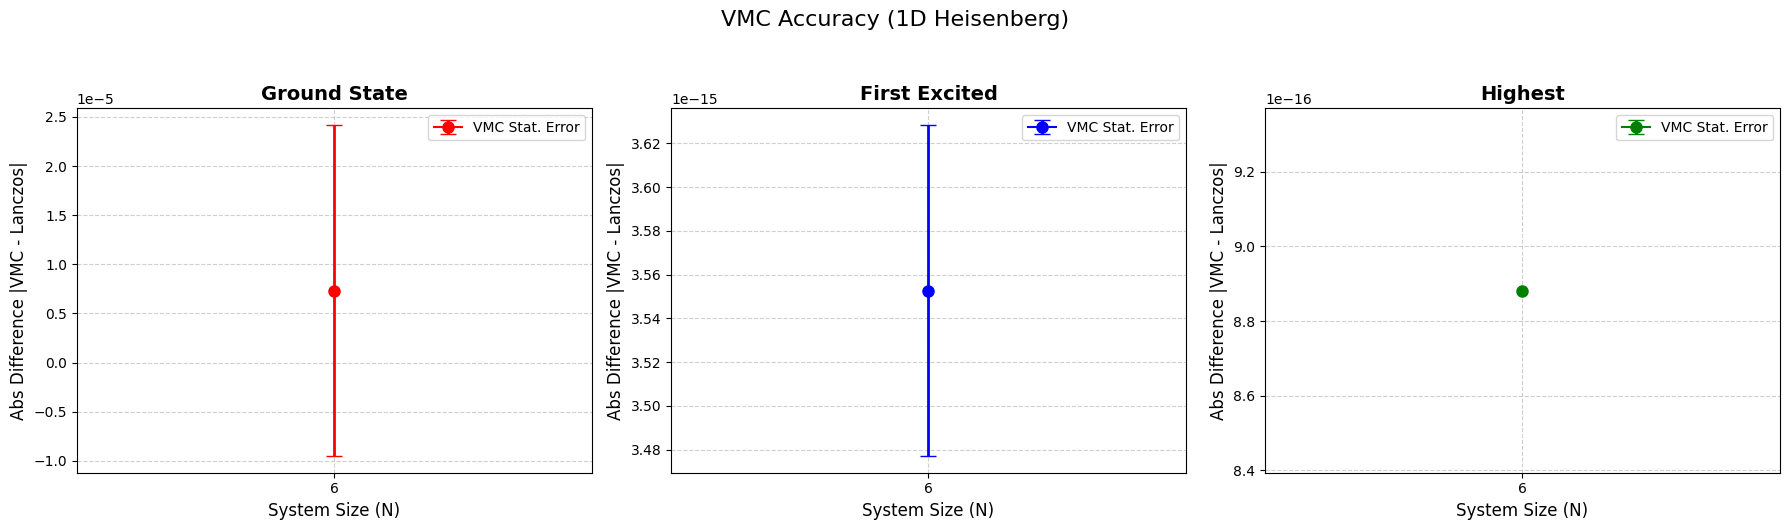

In [5]:
import netket as nk
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def get_lowest_data(n_sites_list):

    results = []

    for n in n_sites_list:
        print(f"--- Analyzing lowest e_val for N = {n} ---")

        graph=nk.graph.Chain(n)
        hi = nk.hilbert.Spin(s=0.5, N=graph.n_nodes)
        hamiltonian = nk.operator.Heisenberg(hilbert=hi, graph=graph)
        e_exact = None
        ed_result = nk.exact.lanczos_ed(hamiltonian, k=1)
        e_exact = float(ed_result[0])

        model = nk.models.RBM(alpha=3, param_dtype=complex)
        sampler = nk.sampler.MetropolisExchange(hi, graph=graph)


        vstate = nk.vqs.MCState(sampler, model, n_samples=1008)


        n_chains = vstate.sampler.n_chains
        neel = np.ones(n)
        neel[1::2] = -1
        neel_samples = np.tile(neel, (n_chains, 1)).astype(np.int8)
        vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array(neel_samples))

        # Optimizer: Stochastic Reconfiguration (SR)
        optimizer = nk.optimizer.Sgd(learning_rate=0.01)  #LEARNING RATE
        #sr = nk.optimizer.SR(diag_shift=0.1)
        #vmc = nk.driver.VMC(hamiltonian, optimizer, variational_state=vstate, preconditioner=sr)
        vmc = nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=vstate)
        # Run Optimization
        vmc.run(n_iter=600)
        energy_stats = vstate.expect(hamiltonian)
        e_vmc = float(energy_stats.mean.real)
        e_error = float(energy_stats.error_of_mean)
        results.append({
            "N": n,
            "VMC": e_vmc,
            "Lanczos": e_exact,
            "diff": abs(e_vmc - e_exact),
            "VMC_err": e_error,
        })

    return results

def get_highest_data(n_sites_list):

    results = []

    for n in n_sites_list:
        print(f"--- Analyzing Highest e_val for N = {n} ---")

        # Lattice and Hamiltonian

        graph=nk.graph.Chain(n)
        hi = nk.hilbert.Spin(s=0.5, N=graph.n_nodes, total_sz=0)
        hamiltonian = -1 * nk.operator.Heisenberg(hilbert=hi, graph=graph)

        e_exact = None
        ed_result = nk.exact.lanczos_ed(hamiltonian, k=1)
        e_exact = -1 * float(ed_result[0])

        model = nk.models.RBM(alpha=2, param_dtype=complex) #RBM DENSITY COEFFICIENT
        sampler = nk.sampler.MetropolisExchange(hi, graph=graph)
        vstate = nk.vqs.MCState(sampler, model, n_samples=1008)


      #all 1 for initial chains option, NOT neel state for highest e_val
        n_chains = vstate.sampler.n_chains
        ferro = np.ones(n)
        ferro_samples = np.tile(ferro, (n_chains, 1)).astype(np.int8)
        vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array(ferro_samples))

        # Optimizer: Stochastic Reconfiguration (SR)
        optimizer = nk.optimizer.Sgd(learning_rate=0.01) #LEARNING RATE
        sr = nk.optimizer.SR(diag_shift=0.1)
        vmc = nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=vstate)
        # Run Optimization
        vmc.run(n_iter=500)
        energy_stats = vstate.expect(hamiltonian)
        e_vmc = -1*float(energy_stats.mean.real)
        e_error = float(energy_stats.error_of_mean)
        results.append({
            "N": n,
            "VMC": e_vmc,
            "Lanczos": e_exact,
            "diff": abs(e_vmc - e_exact),
            "VMC_err": e_error,

        })

    return results
def get_1es_data(n_sites_list):

    results = []

    for n in n_sites_list:
        print(f"--- Analyzing First Excited State for N = {n} ---")

        # Lattice and Hamiltonian

        graph=nk.graph.Chain(n)
        hi = nk.hilbert.Spin(s=0.5, total_sz=1, N=graph.n_nodes)
        lanczos_hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
        hamiltonian = nk.operator.Heisenberg(hilbert=hi, graph=graph)
        lanczos_ham = nk.operator.Heisenberg(hilbert=lanczos_hi, graph=graph)
        e_exact = None
        ed_result = nk.exact.lanczos_ed(lanczos_ham, k=2)
        e_exact = float(ed_result[1])

        #print(f"Lanczos (exact): {e_exact}")
        #Neural Network (RBM)
        model = nk.models.RBM(alpha=2, param_dtype=float) #RBM DENSITY COEFFICIENT
        sampler = nk.sampler.MetropolisExchange(hi, graph=graph) #using Metropolis Exchange bc total_sz = 0

        vstate = nk.vqs.MCState(sampler, model, n_samples=1008)


        # modified Neel state

        n_chains = vstate.sampler.n_chains
        neel = np.ones(n)
        neel[2::2] = -1
        neel_samples = np.tile(neel, (n_chains, 1)).astype(np.int8)
        #print(f"Initial magnetization sum: {jnp.sum(neel_samples[0])}") #total magnetization check
        vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array(neel_samples))

        # Optimizer: Stochastic Reconfiguration (SR)
        optimizer = nk.optimizer.Sgd(learning_rate=0.01)  #LEARNING RATE
        #sr = nk.optimizer.SR(diag_shift=0.1)
        #vmc = nk.driver.VMC(hamiltonian, optimizer, variational_state=vstate, preconditioner=sr)
        vmc = nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=vstate)
        # Run Optimization
        vmc.run(n_iter=500)
        energy_stats = vstate.expect(hamiltonian)
        e_vmc = float(energy_stats.mean.real)
        e_error = float(energy_stats.error_of_mean)
        results.append({
            "N": n,
            "VMC": e_vmc,
            "Lanczos": e_exact,
            "diff": abs(e_vmc - e_exact),
            "VMC_err": e_error,
        })

    return results


def printer(data):
  for d in data:
    status = f"Diff: {d['diff']:.8f}" if d['diff'] is not None else "Exact not computed"
    print(f"N={d['N']} | VMC: {d['VMC']:.8f} | Lanczos: {d['Lanczos']:.8f} | Abs Difference: {d['diff']:.8f} \n")








n_sizes = [6]

results = []
for n in n_sizes:
  data = get_lowest_data([n])
  results.append(data)
  printer(data)
  data = get_1es_data([n])
  results.append(data)
  printer(data)
  data = get_highest_data([n])
  results.append(data)
  printer(data)



